## EDA Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Imports done")

Imports done


In [5]:
df = pd.read_csv('../data/raw_tweets.csv', encoding='latin-1', header=None)
print(f"Total rows: {len(df)}")
print(df.head())

Total rows: 1600000
   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [7]:
df.columns = ['sentiment', 'id', 'date', 'query', 'username', 'text']
print(df.columns.tolist())
print(df['sentiment'].value_counts())

['sentiment', 'id', 'date', 'query', 'username', 'text']
sentiment
0    800000
4    800000
Name: count, dtype: int64


In [8]:
# Map 0 → Negative, 4 → Positive
df['sentiment'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})

# Take a random sample of 10,000 rows
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Sample size: {len(df)}")
print(df['sentiment'].value_counts())
print(df.head(3))

Sample size: 10000
sentiment
Negative    5004
Positive    4996
Name: count, dtype: int64
  sentiment          id                          date     query  \
0  Negative  2200003196  Tue Jun 16 18:18:12 PDT 2009  NO_QUERY   
1  Negative  1467998485  Mon Apr 06 23:11:14 PDT 2009  NO_QUERY   
2  Negative  2300048954  Tue Jun 23 13:40:11 PDT 2009  NO_QUERY   

          username                                               text  
0  LaLaLindsey0609             @chrishasboobs AHHH I HOPE YOUR OK!!!   
1      sexygrneyes  @misstoriblack cool , i have no tweet apps  fo...  
2       sammydearr  @TiannaChaos i know  just family drama. its la...  


In [9]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nEmpty text rows: {df['text'].str.strip().eq('').sum()}")

Missing values:
sentiment    0
id           0
date         0
query        0
username     0
text         0
dtype: int64

Empty text rows: 0


Average tweet length: 74.4 chars
Shortest tweet: 8 chars
Longest tweet: 213 chars


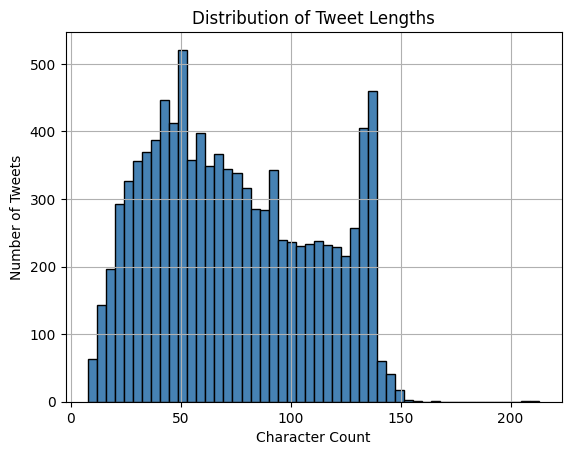

In [10]:
df['text_length'] = df['text'].str.len()

print(f"Average tweet length: {df['text_length'].mean():.1f} chars")
print(f"Shortest tweet: {df['text_length'].min()} chars")
print(f"Longest tweet: {df['text_length'].max()} chars")

df['text_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Character Count')
plt.ylabel('Number of Tweets')
plt.show()